# AnyLabel/LabelMe Nail Segmentation → 1.02× ROI Crop Pipeline

Goal: turn original finger images + AnyLabel/LabelMe JSON polygons into **proper nail crops** without quality loss.

This notebook does segmentation crop and ROI scaling in **one step**:

1. Read image + matching JSON.
2. Build nail mask from `TARGET_LABELS`.
3. Subtract `EXCLUDE_LABELS` such as `free_edge`.
4. Compute the nail bounding box.
5. Expand that bbox by `ROI_SCALE = 1.02` directly on the **original image coordinates**.
6. Save the crop as **PNG lossless**.
7. Save CSV reports so you can check missing images, skipped JSON, and crop sizes.

Why this is better than crop → ROI-scale later: once a tight crop is already made, pixels outside that crop are gone. Expanding directly from the original image preserves the available surrounding nail pixels and avoids interpolation/resizing quality loss.


In [1]:
# Install only if needed
# %pip install opencv-python pillow pandas tqdm matplotlib


In [1]:
from pathlib import Path
import json
import math
import shutil
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display
import matplotlib.pyplot as plt

# =========================
# EDIT THESE PATHS
# =========================
IMAGES_DIR = Path(r'/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/organizing/eyeimage5_organized_exact_copy/unusable/polish/polish_images')      # folder containing original .jpg/.png images
JSON_DIR   = Path(r'/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/organizing/eyeimage5_organized_exact_copy/unusable/polish/polish_json')        # folder containing AnyLabel/LabelMe .json files
OUT_DIR    = Path(r"/Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/polish_output/polish_nail_crops_roi102_flat")

# Labels inside the JSON
TARGET_LABELS  = {"nail"}
EXCLUDE_LABELS = {"free_edge"}       # removed from nail mask; set() if you do not use this label

# Crop behavior
ROI_SCALE = 1.02                     # 1.02 means 2% larger bbox around nail center
DILATE_EXCLUDE_PX = 0                # optional: expand free_edge removal area; 0 = off
MIN_MASK_PIXELS = 20                 # very small masks are usually annotation mistakes/noise

# Output behavior
SAVE_MODE = "black_bg"              # "black_bg", "transparent", or "original_bg"
SAVE_MASKS = True                    # save binary mask crop for checking
SAVE_OVERLAYS = True                 # save quick visual overlays for checking
MIRROR_JSON_SUBFOLDERS = False       # True keeps JSON subfolder structure in output

# Image extensions to search when matching JSON stem
IMG_EXTS = [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".JPG", ".JPEG", ".PNG"]

OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "_reports").mkdir(parents=True, exist_ok=True)
if SAVE_MASKS:
    (OUT_DIR / "_masks").mkdir(parents=True, exist_ok=True)
if SAVE_OVERLAYS:
    (OUT_DIR / "_overlays").mkdir(parents=True, exist_ok=True)

print("IMAGES_DIR:", IMAGES_DIR)
print("JSON_DIR  :", JSON_DIR)
print("OUT_DIR   :", OUT_DIR)


IMAGES_DIR: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/organizing/eyeimage5_organized_exact_copy/unusable/polish/polish_images
JSON_DIR  : /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/organizing/eyeimage5_organized_exact_copy/unusable/polish/polish_json
OUT_DIR   : /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/polish_output/polish_nail_crops_roi102_flat


/opt/anaconda3/envs/nail_preprocess/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def norm_label(x):
    """Normalize label text so ' Nail ' and 'nail' match."""
    return str(x).strip().lower()

TARGET_LABELS_N = {norm_label(x) for x in TARGET_LABELS}
EXCLUDE_LABELS_N = {norm_label(x) for x in EXCLUDE_LABELS}

def find_image_for_json(json_path: Path, images_dir: Path, data: dict | None = None):
    """Find image by JSON imagePath first, then by matching filename stem recursively."""
    candidates = []

    # 1) imagePath inside LabelMe/AnyLabel JSON
    if data:
        image_path = data.get("imagePath")
        if image_path:
            ip = Path(image_path)
            candidates += [json_path.parent / ip, images_dir / ip.name, images_dir / ip]

    # 2) same stem in image folder or subfolders
    stem = json_path.stem
    for ext in IMG_EXTS:
        candidates.append(images_dir / f"{stem}{ext}")
    for ext in IMG_EXTS:
        candidates.extend(images_dir.rglob(f"{stem}{ext}"))

    seen = set()
    for c in candidates:
        c = Path(c)
        if c in seen:
            continue
        seen.add(c)
        if c.exists() and c.is_file():
            return c
    return None

def read_image_bgr(path: Path):
    """Read image as BGR with OpenCV. Handles common unicode path issues."""
    arr = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return img

def write_png(path: Path, img):
    """Write PNG losslessly, robust to unicode paths."""
    path.parent.mkdir(parents=True, exist_ok=True)
    ok, buf = cv2.imencode('.png', img)
    if not ok:
        raise RuntimeError(f"cv2.imencode failed: {path}")
    buf.tofile(str(path))

def polygon_to_mask(points, h, w):
    """Create a 0/1 mask from polygon points."""
    pts = np.asarray(points, dtype=np.float32)
    if pts.ndim != 2 or pts.shape[0] < 3 or pts.shape[1] != 2:
        return np.zeros((h, w), dtype=np.uint8)
    pts[:, 0] = np.clip(np.round(pts[:, 0]), 0, w - 1)
    pts[:, 1] = np.clip(np.round(pts[:, 1]), 0, h - 1)
    pts = pts.astype(np.int32)
    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def bbox_from_mask(mask01):
    ys, xs = np.where(mask01 > 0)
    if xs.size == 0 or ys.size == 0:
        return None
    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

def expand_bbox(bbox, scale, img_w, img_h):
    """Expand bbox around its center and clip to original image boundaries. No resizing."""
    x0, y0, x1, y1 = bbox
    bw = x1 - x0 + 1
    bh = y1 - y0 + 1
    cx = (x0 + x1) / 2.0
    cy = (y0 + y1) / 2.0
    new_w = max(1, int(math.ceil(bw * scale)))
    new_h = max(1, int(math.ceil(bh * scale)))
    nx0 = int(math.floor(cx - new_w / 2.0))
    ny0 = int(math.floor(cy - new_h / 2.0))
    nx1 = nx0 + new_w - 1
    ny1 = ny0 + new_h - 1

    # clip to image, do not pad black outside the original image
    nx0 = max(0, nx0)
    ny0 = max(0, ny0)
    nx1 = min(img_w - 1, nx1)
    ny1 = min(img_h - 1, ny1)
    return nx0, ny0, nx1, ny1

def make_crop(img_bgr, mask01, crop_bbox, save_mode="black_bg"):
    x0, y0, x1, y1 = crop_bbox
    crop_img = img_bgr[y0:y1+1, x0:x1+1].copy()
    crop_mask01 = mask01[y0:y1+1, x0:x1+1].astype(np.uint8)
    crop_mask255 = crop_mask01 * 255

    if save_mode == "original_bg":
        return crop_img, crop_mask255

    if save_mode == "black_bg":
        masked = np.zeros_like(crop_img)
        masked[crop_mask01 > 0] = crop_img[crop_mask01 > 0]
        return masked, crop_mask255

    if save_mode == "transparent":
        bgra = cv2.cvtColor(crop_img, cv2.COLOR_BGR2BGRA)
        bgra[:, :, 3] = crop_mask255
        return bgra, crop_mask255

    raise ValueError("SAVE_MODE must be 'black_bg', 'transparent', or 'original_bg'")

def make_overlay(img_bgr, mask01, crop_bbox):
    x0, y0, x1, y1 = crop_bbox
    crop = img_bgr[y0:y1+1, x0:x1+1].copy()
    m = mask01[y0:y1+1, x0:x1+1].astype(bool)
    overlay = crop.copy()
    # green-ish overlay without changing saved training crop
    overlay[m] = (0.55 * overlay[m] + 0.45 * np.array([0, 255, 0])).astype(np.uint8)
    return overlay


In [3]:
json_files = sorted(JSON_DIR.rglob("*.json"))
print("Found JSON files:", len(json_files))

records = []
missing_records = []
exported = 0

for jp in tqdm(json_files):
    try:
        data = json.loads(jp.read_text(encoding="utf-8"))
    except Exception as e:
        missing_records.append({"json": str(jp), "reason": f"bad_json: {e}"})
        continue

    img_path = find_image_for_json(jp, IMAGES_DIR, data)
    if img_path is None:
        missing_records.append({"json": str(jp), "reason": "matching_image_not_found"})
        continue

    img_bgr = read_image_bgr(img_path)
    if img_bgr is None:
        missing_records.append({"json": str(jp), "image": str(img_path), "reason": "image_read_failed"})
        continue

    h, w = img_bgr.shape[:2]
    shapes = data.get("shapes", [])

    nail_shapes = []
    exclude_shapes = []
    for s in shapes:
        label = norm_label(s.get("label", ""))
        points = s.get("points", [])
        if len(points) < 3:
            continue
        if label in TARGET_LABELS_N:
            nail_shapes.append(s)
        if label in EXCLUDE_LABELS_N:
            exclude_shapes.append(s)

    if not nail_shapes:
        missing_records.append({"json": str(jp), "image": str(img_path), "reason": "no_target_label"})
        continue

    # Combined exclude mask: free_edge union
    exclude_mask = np.zeros((h, w), dtype=np.uint8)
    for s in exclude_shapes:
        exclude_mask |= polygon_to_mask(s["points"], h, w)

    if DILATE_EXCLUDE_PX > 0 and exclude_mask.any():
        k = 2 * DILATE_EXCLUDE_PX + 1
        kernel = np.ones((k, k), np.uint8)
        exclude_mask = cv2.dilate(exclude_mask, kernel, iterations=1)

    for idx, s in enumerate(nail_shapes, start=1):
        nail_mask = polygon_to_mask(s["points"], h, w)
        final_mask = (nail_mask & (exclude_mask == 0)).astype(np.uint8)
        mask_pixels = int(final_mask.sum())

        if mask_pixels < MIN_MASK_PIXELS:
            missing_records.append({
                "json": str(jp), "image": str(img_path), "nail_index": idx,
                "reason": f"tiny_mask_pixels_{mask_pixels}"
            })
            continue

        bbox = bbox_from_mask(final_mask)
        if bbox is None:
            missing_records.append({"json": str(jp), "image": str(img_path), "nail_index": idx, "reason": "empty_mask"})
            continue

        crop_bbox = expand_bbox(bbox, ROI_SCALE, w, h)
        crop_img, crop_mask = make_crop(img_bgr, final_mask, crop_bbox, save_mode=SAVE_MODE)

        if MIRROR_JSON_SUBFOLDERS:
            rel_parent = jp.parent.relative_to(JSON_DIR)
            out_sub = OUT_DIR / rel_parent / jp.stem
        else:
            out_sub = OUT_DIR / jp.stem
        out_sub.mkdir(parents=True, exist_ok=True)

        out_img = out_sub / f"{jp.stem}_nail_{idx:02d}.png"
        write_png(out_img, crop_img)

        out_mask = ""
        if SAVE_MASKS:
            out_mask_path = OUT_DIR / "_masks" / f"{jp.stem}_nail_{idx:02d}_mask.png"
            write_png(out_mask_path, crop_mask)
            out_mask = str(out_mask_path)

        out_overlay = ""
        if SAVE_OVERLAYS:
            overlay = make_overlay(img_bgr, final_mask, crop_bbox)
            out_overlay_path = OUT_DIR / "_overlays" / f"{jp.stem}_nail_{idx:02d}_overlay.png"
            write_png(out_overlay_path, overlay)
            out_overlay = str(out_overlay_path)

        x0, y0, x1, y1 = bbox
        cx0, cy0, cx1, cy1 = crop_bbox
        records.append({
            "json": str(jp),
            "image": str(img_path),
            "nail_index": idx,
            "output_png": str(out_img),
            "mask_png": out_mask,
            "overlay_png": out_overlay,
            "image_w": w,
            "image_h": h,
            "mask_pixels": mask_pixels,
            "bbox_x0": x0, "bbox_y0": y0, "bbox_x1": x1, "bbox_y1": y1,
            "crop_x0": cx0, "crop_y0": cy0, "crop_x1": cx1, "crop_y1": cy1,
            "crop_w": cx1 - cx0 + 1,
            "crop_h": cy1 - cy0 + 1,
            "roi_scale": ROI_SCALE,
            "save_mode": SAVE_MODE,
        })
        exported += 1

report_df = pd.DataFrame(records)
missing_df = pd.DataFrame(missing_records)

report_path = OUT_DIR / "_reports" / "crop_report.csv"
missing_path = OUT_DIR / "_reports" / "missing_or_skipped_report.csv"
report_df.to_csv(report_path, index=False)
missing_df.to_csv(missing_path, index=False)

print("Done")
print("Exported crops:", exported)
print("Skipped/missing:", len(missing_df))
print("Report:", report_path)
print("Missing/skipped report:", missing_path)
report_df.head()


Found JSON files: 108


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 108/108 [00:15<00:00,  7.09it/s]

Done
Exported crops: 451
Skipped/missing: 1
Report: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/polish_output/polish_nail_crops_roi102_flat/_reports/crop_report.csv
Missing/skipped report: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/polish_output/polish_nail_crops_roi102_flat/_reports/missing_or_skipped_report.csv


,json,image,nail_index,output_png,mask_png,overlay_png,image_w,image_h,mask_pixels,bbox_x0,...,bbox_x1,bbox_y1,crop_x0,crop_y0,crop_x1,crop_y1,crop_w,crop_h,roi_scale,save_mode
0,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,1,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,2448,3264,25757,1269,...,1409,2986,1267,2709,1410,2988,144,280,1.02,black_bg
1,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,1,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,2448,3264,92063,44,...,331,2278,40,1887,333,2281,294,395,1.02,black_bg
2,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,2,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,2448,3264,85559,822,...,1104,2460,818,2091,1106,2463,289,373,1.02,black_bg
3,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,3,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,2448,3264,72611,1638,...,1914,2266,1634,1949,1916,2269,283,321,1.02,black_bg
4,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,1,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,2448,3264,19921,157,...,305,2009,155,1830,306,2010,152,181,1.02,black_bg


In [4]:
# Quality check 1: confirm every saved training crop is PNG and can be opened
crop_paths = [Path(p) for p in report_df.get("output_png", [])]
problems = []
for p in crop_paths:
    try:
        with Image.open(p) as im:
            im.verify()
    except Exception as e:
        problems.append({"file": str(p), "problem": str(e)})

print("Crops checked:", len(crop_paths))
print("Open/read problems:", len(problems))
if problems:
    display(pd.DataFrame(problems).head(20))
else:
    print("All saved crops are readable PNG files.")


Crops checked: 451
Open/read problems: 0
All saved crops are readable PNG files.


20211012161255_pid2625_hf5gbs_nail_02.png


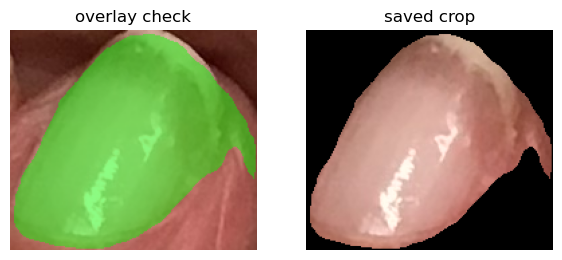

20210719175647_pid2625_vM6cZv_nail_05.png


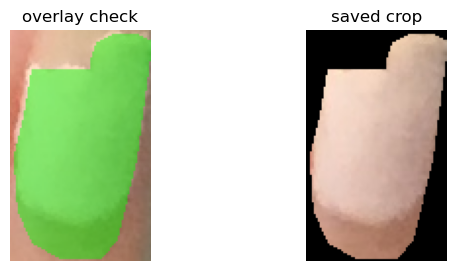

20220411150053_pid2625_Pb79Bn_nail_05.png


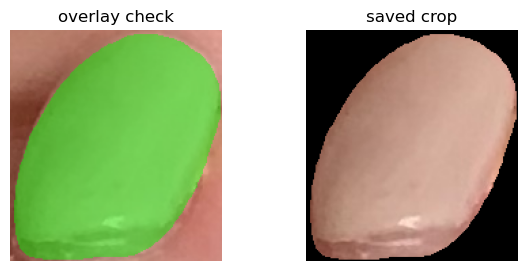

20220613110405_pid2625_SMRTjy_nail_04.png


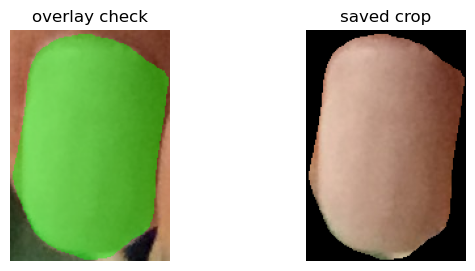

20220216124324_pid2625_BWjv9W_nail_05.png


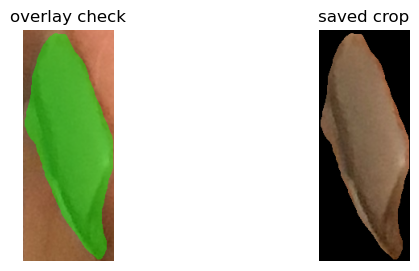

20211015104622_pid2625_jQRzwB_nail_02.png


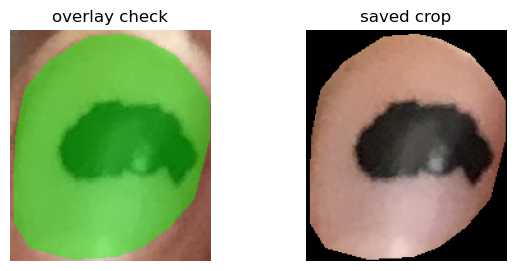

20210618114309_pid2625_sVV9J3_nail_05.png


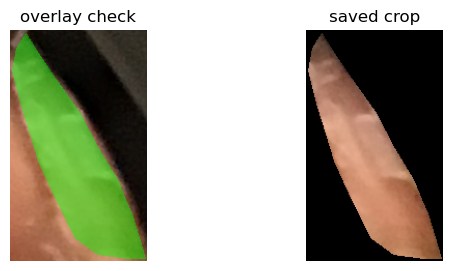

20221115135602_pid2625_3SHhdJ_nail_01.png


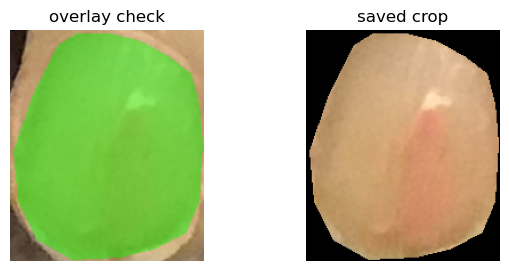

In [5]:
# Quality check 2: show random overlays and final crops side-by-side
# Green overlay = kept nail region. Final crop = what goes into model/preprocessing.

if len(report_df) == 0:
    print("No crops to preview.")
else:
    n = min(8, len(report_df))
    sample_df = report_df.sample(n=n, random_state=0) if len(report_df) > n else report_df

    for _, row in sample_df.iterrows():
        print(Path(row["output_png"]).name)
        fig, axes = plt.subplots(1, 2, figsize=(7, 3))

        if row.get("overlay_png") and Path(row["overlay_png"]).exists():
            overlay_bgr = read_image_bgr(Path(row["overlay_png"]))
            axes[0].imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
            axes[0].set_title("overlay check")
        else:
            axes[0].text(0.5, 0.5, "no overlay", ha="center")
        axes[0].axis("off")

        crop = Image.open(row["output_png"])
        axes[1].imshow(crop if crop.mode != "RGBA" else crop.convert("RGBA"))
        axes[1].set_title("saved crop")
        axes[1].axis("off")
        plt.show()


In [6]:
# Quality check 3: inspect suspicious crops by size or mask area
# These are not automatically wrong. They are just the best candidates for manual checking.

if len(report_df) > 0:
    check_df = report_df.copy()
    check_df["aspect_ratio"] = check_df["crop_w"] / check_df["crop_h"].replace(0, np.nan)
    suspicious = check_df[
        (check_df["crop_w"] < 20) |
        (check_df["crop_h"] < 20) |
        (check_df["mask_pixels"] < 100) |
        (check_df["aspect_ratio"] > 5) |
        (check_df["aspect_ratio"] < 0.2)
    ].copy()
    suspicious_path = OUT_DIR / "_reports" / "suspicious_crops_to_review.csv"
    suspicious.to_csv(suspicious_path, index=False)
    print("Suspicious crops:", len(suspicious))
    print("Saved:", suspicious_path)
    display(suspicious.head(30))
else:
    print("No report rows available.")


Suspicious crops: 0
Saved: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will data/pre_process/seg_scale/polish_output/polish_nail_crops_roi102_flat/_reports/suspicious_crops_to_review.csv


,json,image,nail_index,output_png,mask_png,overlay_png,image_w,image_h,mask_pixels,bbox_x0,...,bbox_y1,crop_x0,crop_y0,crop_x1,crop_y1,crop_w,crop_h,roi_scale,save_mode,aspect_ratio


## How to judge finished

You are finished when:

- `crop_report.csv` has one row for every nail polygon you expect.
- `missing_or_skipped_report.csv` is empty or only contains cases you intentionally ignore.
- The overlay previews show the nail area correctly, with `free_edge` removed when labeled.
- `suspicious_crops_to_review.csv` has no real mistakes after manual checking.
- The saved crops are `.png`, and this notebook never resizes the original pixels, so it avoids interpolation and JPEG re-compression loss.
